In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


1A. Normalization Comparison

Build the following CNN architecture (call it "BaselineCNN"):

Experiment A

No normalization (raw pixel values 0–255)

as it is in model --> no preprocessing on input

In [3]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow import keras

def BaselineCNN():
  model1 = Sequential()
  model1.add(keras.Input(shape=(32,32,3)))
  model1.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model1.add(MaxPooling2D((2,2)))

  model1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model1.add(MaxPooling2D((2,2)))

  # flatten layer
  model1.add(Flatten())

  # fully connected layer
  model1.add(Dense(128, activation='relu'))

  # output layer
  model1.add(Dense(10, activation='softmax'))

  model1.compile(
      optimizer= Adam(learning_rate=0.001),
      loss= 'categorical_crossentropy',
      metrics=['accuracy']
  )
  return model1

In [4]:
# callbacks : early_stopping , reduce_LR , modelcheckpoint
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model1 = BaselineCNN()

history1 = model1.fit(
    x_train, to_categorical(y_train, 10),
    validation_data=(x_val, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)


I0000 00:00:1776717541.436693      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776717541.442620      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1776717545.230034     128 service.cc:152] XLA service 0x7e20a8005640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776717545.230078     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776717545.230084     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776717545.559828     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


 30/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1105 - loss: 74.6740

I0000 00:00:1776717548.092842     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2288 - loss: 15.5568 - val_accuracy: 0.4380 - val_loss: 1.5356
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4728 - loss: 1.4684 - val_accuracy: 0.5043 - val_loss: 1.3873
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5525 - loss: 1.2589 - val_accuracy: 0.5423 - val_loss: 1.3073
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5997 - loss: 1.1294 - val_accuracy: 0.5019 - val_loss: 1.4539
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6213 - loss: 1.0625 - val_accuracy: 0.5651 - val_loss: 1.2917
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6710 - loss: 0.9398 - val_accuracy: 0.5621 - val_loss: 1.3825
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6903 - loss: 0.8737 - val_accuracy: 0.5545 - val_loss: 1.4205
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7099 - loss: 0.8241 - val_accuracy: 0.5617 - va

Experiment B : Min-Max normalization: x / 255.0 → range [0, 1]

In [5]:
# Min-Max normalization
x_train= x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

def exper_B():
  model2 = Sequential()
  model2.add(keras.Input(shape=(32,32,3)))
  model2.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model2.add(MaxPooling2D((2,2)))

  model2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model2.add(MaxPooling2D((2,2)))

  # flatten layer
  model2.add(Flatten())

  # fully connected layer
  model2.add(Dense(128, activation='relu'))

  # output layer
  model2.add(Dense(10, activation='softmax'))

  model2.compile(
      optimizer= Adam(learning_rate=0.001),
      loss= 'categorical_crossentropy',
      metrics=['accuracy']
  )
  return model2

In [6]:
# callbacks : early_stopping , reduce_LR , modelcheckpoint
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model2 = exper_B()

history2 = model2.fit(
    x_train, to_categorical(y_train, 10),
    validation_data=(x_val, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],

)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3315 - loss: 1.8378 - val_accuracy: 0.5385 - val_loss: 1.3345
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5531 - loss: 1.2691 - val_accuracy: 0.6072 - val_loss: 1.1482
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6156 - loss: 1.0954 - val_accuracy: 0.6297 - val_loss: 1.0764
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6533 - loss: 0.9937 - val_accuracy: 0.6504 - val_loss: 1.0154
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6787 - loss: 0.9222 - val_accuracy: 0.6602 - val_loss: 0.9825
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7027 - loss: 0.8623 - val_accuracy: 0.6665 - val_loss: 0.9654
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7194 - loss: 0.8040 - val_accuracy: 0.6754 - val_loss: 0.9492
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7379 - loss: 0.7523 - val_accuracy: 0

Experiment C: Standardization per-channel: x' = (x − mean) / std
(compute mean & std from training set ONLY)

In [7]:
Xmean=np.mean(x_train, axis=(0,1,2,3))
Xstd=np.std(x_train , axis=(0,1,2,3))
x_train_standarized=(x_train - Xmean)/Xstd
x_val_standarized=(x_val - Xmean)/Xstd
x_test_standarized=(x_test - Xmean)/Xstd

from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

def exper_C():
  model3 = Sequential()
  model3.add(keras.Input(shape=(32,32,3)))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  # flatten layer
  model3.add(Flatten())

  # fully connected layer
  model3.add(Dense(128, activation='relu'))

  # output layer
  model3.add(Dense(10, activation='softmax'))

  model3.compile(
      optimizer= Adam(learning_rate=0.001),
      loss= 'categorical_crossentropy',
      metrics=['accuracy']
  )
  return model3

In [8]:
# callbacks : early_stopping , reduce_LR , modelcheckpoint
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model3 = exper_C()

history3 = model3.fit(
    x_train_standarized, to_categorical(y_train, 10),
    validation_data=(x_val_standarized, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4073 - loss: 1.6535 - val_accuracy: 0.6043 - val_loss: 1.1430
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6384 - loss: 1.0473 - val_accuracy: 0.6503 - val_loss: 1.0126
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6946 - loss: 0.8826 - val_accuracy: 0.6702 - val_loss: 0.9632
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7349 - loss: 0.7742 - val_accuracy: 0.6822 - val_loss: 0.9426
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7628 - loss: 0.6913 - val_accuracy: 0.6790 - val_loss: 0.9607
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7872 - loss: 0.6196 - val_accuracy: 0.6722 - val_loss: 1.0192
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8092 - loss: 0.5597 - val_accuracy: 0.6769 - val_loss: 1.0499
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8273 - loss: 0.5055 - val_accuracy: 0

Plot: training loss curves — all 3 on ONE graph

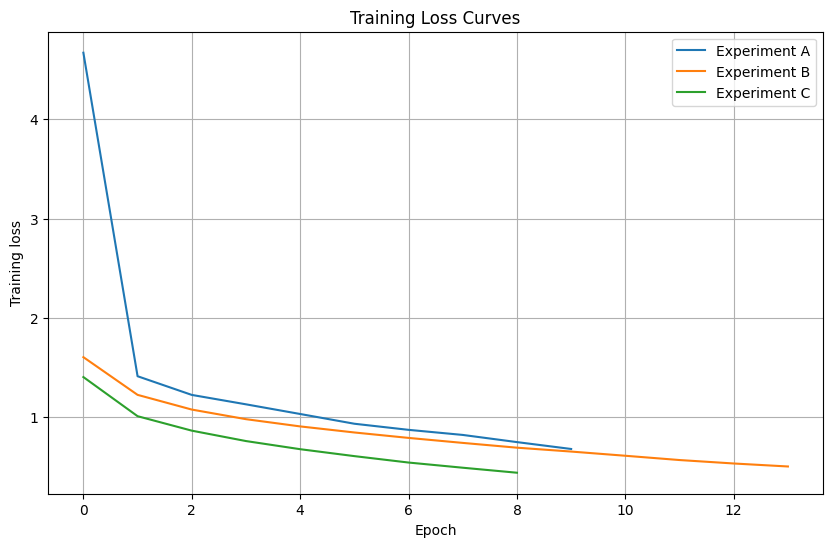

In [9]:
plt.figure(figsize=(10,6))

plt.plot(history1.history['loss'], label='Experiment A')
plt.plot(history2.history['loss'], label='Experiment B')
plt.plot(history3.history['loss'], label='Experiment C')

plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

Plot: validation accuracy curves — all 3 on ONE graph

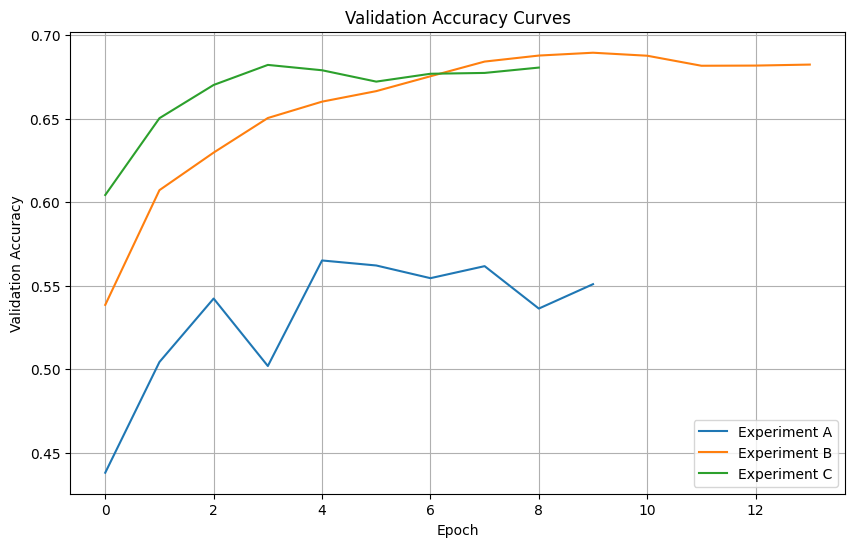

In [10]:
plt.figure(figsize=(10,6))

plt.plot(history1.history['val_accuracy'], label='Experiment A')
plt.plot(history2.history['val_accuracy'], label='Experiment B')
plt.plot(history3.history['val_accuracy'], label='Experiment C')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

test accuracy for experiment A

In [11]:
test_loss, test_accuracy = model1.evaluate(
    x_test, to_categorical(y_test, 10)
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1037 - loss: 2.3134
Test Accuracy: 0.10010000318288803


test accuracy for experiment B

In [12]:
test_loss, test_accuracy = model2.evaluate(
    x_test, to_categorical(y_test, 10)
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6876 - loss: 0.9094
Test Accuracy: 0.6830000281333923


test accuracy for Experiment C

In [13]:
test_loss, test_accuracy = model3.evaluate(
    x_test_standarized, to_categorical(y_test, 10)
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6816 - loss: 0.9337
Test Accuracy: 0.679099977016449


1B. Data Augmentation Comparison

Using the standardized data from Exp C, train the BaselineCNN with and without data augmentation.

In [14]:
model_no_aug = exper_C()
from tensorflow.keras.callbacks import EarlyStopping

early_stop_c=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_no_aug = model_no_aug.fit(
    x_train_standarized, to_categorical(y_train, 10),
    validation_data=(x_val_standarized, to_categorical(y_val, 10)),
    epochs=40,
    batch_size=128,
    callbacks=[early_stop_c]
)


Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4096 - loss: 1.6472 - val_accuracy: 0.6045 - val_loss: 1.1445
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6284 - loss: 1.0624 - val_accuracy: 0.6558 - val_loss: 0.9993
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6943 - loss: 0.8848 - val_accuracy: 0.6803 - val_loss: 0.9347
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7349 - loss: 0.7683 - val_accuracy: 0.6816 - val_loss: 0.9471
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7657 - loss: 0.6814 - val_accuracy: 0.6919 - val_loss: 0.9402
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7946 - loss: 0.6018 - val_accuracy: 0.6772 - val_loss: 1.0199
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8131 - loss: 0.5446 - val_accuracy: 0.6846 - val_loss: 1.0262
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8281 - loss: 0.4973 - val_accuracy: 0

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_standarized)

early_stop_c2=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_aug = exper_C()
history_aug = model_aug.fit(
    datagen.flow(x_train_standarized, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_standarized, to_categorical(y_val, 10)),
    epochs=40,
    batch_size=128,
    callbacks=[early_stop_c2]
)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.3861 - loss: 1.7105 - val_accuracy: 0.5831 - val_loss: 1.2054
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.5657 - loss: 1.2188 - val_accuracy: 0.6437 - val_loss: 1.0257
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6125 - loss: 1.0947 - val_accuracy: 0.6494 - val_loss: 1.0087
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6462 - loss: 1.0134 - val_accuracy: 0.6741 - val_loss: 0.9532
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6605 - loss: 0.9609 - val_accuracy: 0.7093 - val_loss: 0.8435
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6746 - loss: 0.9201 - val_accuracy: 0.6722 - val_loss: 0.9560
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6900 - loss: 0.8851 - val_accuracy: 0.7101 - val_loss: 0.8440
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6988 - loss: 0.8578 - val_accurac

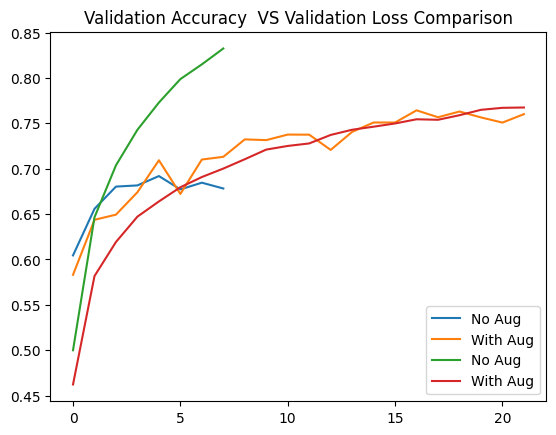

In [16]:
import matplotlib.pyplot as plt

# Validation and Training Accuracy
plt.plot(history_no_aug.history['val_accuracy'], label='No Aug')
plt.plot(history_aug.history['val_accuracy'], label='With Aug')
plt.plot(history_no_aug.history['accuracy'], label='No Aug')
plt.plot(history_aug.history['accuracy'], label='With Aug')
plt.title('Validation Accuracy  VS Validation Loss Comparison')
plt.legend()
plt.show()

Report the gap (train_acc − val_acc) at epoch 40 for each. Which one overfits less?

With Augmentation

Gap = (train_acc - val_acc)


In [17]:
train_acc = history_no_aug.history['accuracy'][-1]
val_acc = history_no_aug.history['val_accuracy'][-1]
gap1 = train_acc - val_acc

# -1 ---> refer to the last epoch here (40)

train_acc2 = history_aug.history['accuracy'][-1]
val_acc2 = history_aug.history['val_accuracy'][-1]
gap2 = train_acc2 - val_acc2

print("Gap wihtout Augmentation: ", gap1)
print("Gap with Augmentation: ", gap2)

Gap wihtout Augmentation:  0.15424996614456177
Gap with Augmentation:  0.00732499361038208


Task 2: CNN Architecture Experiments
Use standardized data for ALL experiments in this task.

2A. Filter Count Comparison

In [18]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

def filters(f1 , f2 , f3 , f4):
  model3 = Sequential()
  model3.add(keras.Input(shape=(32,32,3)))
  model3.add(Conv2D(f1, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(Conv2D(f2, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(f3, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(f4, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  # flatten layer
  model3.add(Flatten())

  # fully connected layer
  model3.add(Dense(256, activation='relu'))

  # output layer
  model3.add(Dense(10, activation='softmax'))

  model3.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
  return model3

In [19]:
small_model=filters(8,8,16,16)
small_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
medium_model=filters(32,32,64,64)
medium_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
large_model=filters(64,64,128,128)
large_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
def train_model(model3):
    start = time.time()

    early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )
    elapsed = time.time() - start

    history = model3.fit(
        x_train, to_categorical(y_train, 10),
        validation_data=(x_val, to_categorical(y_val, 10)),
        epochs=20,
        batch_size=128,
        callbacks=[early_stop]
    )

    test_loss, test_acc = model3.evaluate(
        x_test_standarized, to_categorical(y_test, 10)
    )

    return history, test_acc, elapsed

In [23]:
h_small, test_small, time_small = train_model(small_model)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3048 - loss: 1.9047 - val_accuracy: 0.4838 - val_loss: 1.4577
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5034 - loss: 1.3821 - val_accuracy: 0.5551 - val_loss: 1.2637
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5647 - loss: 1.2224 - val_accuracy: 0.5836 - val_loss: 1.1833
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6029 - loss: 1.1189 - val_accuracy: 0.5973 - val_loss: 1.1403
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6326 - loss: 1.0445 - val_accuracy: 0.6191 - val_loss: 1.0913
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6610 - loss: 0.9657 - val_accuracy: 0.6251 - val_loss: 1.0655
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6850 - loss: 0.8992 - val_accuracy: 0.6325 - val_loss: 1.0574
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7073 - loss: 0.8362 - val_accuracy: 0

In [24]:
h_medium, test_medium, time_medium = train_model(medium_model)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3469 - loss: 1.7837 - val_accuracy: 0.5728 - val_loss: 1.2077
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5993 - loss: 1.1224 - val_accuracy: 0.6556 - val_loss: 0.9843
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6887 - loss: 0.8813 - val_accuracy: 0.6955 - val_loss: 0.8839
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7416 - loss: 0.7307 - val_accuracy: 0.7164 - val_loss: 0.8282
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7856 - loss: 0.6181 - val_accuracy: 0.7225 - val_loss: 0.8321
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8158 - loss: 0.5264 - val_accuracy: 0.7231 - val_loss: 0.8822
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8382 - loss: 0.4608 - val_accuracy: 0.7219 - val_loss: 0.9609
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8733 - loss: 0.3636 - val_acc

In [25]:
h_large, test_large, time_large = train_model(large_model)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3624 - loss: 1.7421 - val_accuracy: 0.5854 - val_loss: 1.1587
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6261 - loss: 1.0520 - val_accuracy: 0.6794 - val_loss: 0.9178
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7156 - loss: 0.8119 - val_accuracy: 0.7124 - val_loss: 0.8634
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7744 - loss: 0.6520 - val_accuracy: 0.7155 - val_loss: 0.8597
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8197 - loss: 0.5241 - val_accuracy: 0.7336 - val_loss: 0.8565
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8519 - loss: 0.4218 - val_accuracy: 0.7264 - val_loss: 0.9881
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8863 - loss: 0.3230 - val_accuracy: 0.7228 - val_loss: 1.0720
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9113 - loss: 0.2518 - val_acc

11. Plot: val accuracy curves for all 3 on one graph

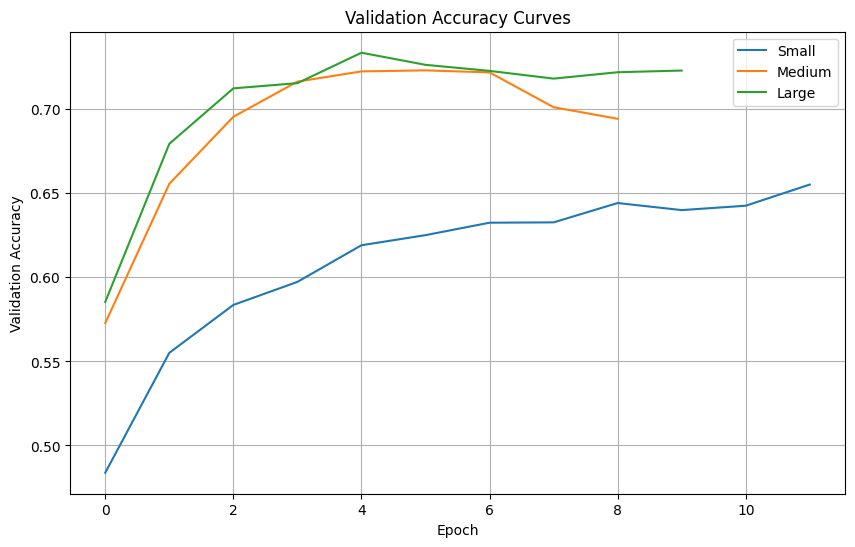

In [26]:
plt.figure(figsize=(10,6))

plt.plot(h_small.history['val_accuracy'], label='Small')
plt.plot(h_medium.history['val_accuracy'], label='Medium')
plt.plot(h_large.history['val_accuracy'], label='Large')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

2C. Network Depth Comparison


All use 32 filters, kernel 3×3, ReLU, padding='same'. Build 3 models with different depths:

Shallow (4 conv layers):

In [27]:
from tensorflow.keras.layers import Conv2D , MaxPooling2D , GlobalAveragePooling2D
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

def shallow_model():
  model3 = Sequential()
  model3.add(keras.Input(shape=(32,32,3)))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  # flatten layer
  model3.add(Flatten())

  # fully connected layer
  model3.add(Dense(256, activation='relu'))

  # output layer
  model3.add(Dense(10, activation='softmax'))

  model3.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
  return model3

Medium (6 conv layers):

In [28]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

def Medium_model():
  model3 = Sequential()
  model3.add(keras.Input(shape=(32,32,3)))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(GlobalAveragePooling2D())

  # flatten layer
  model3.add(Flatten())

  # fully connected layer
  model3.add(Dense(256, activation='relu'))

  # output layer
  model3.add(Dense(10, activation='softmax'))

  model3.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
  return model3

Deep (8 conv layers):

In [29]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

def Deep_model():
  model3 = Sequential()
  model3.add(keras.Input(shape=(32,32,3)))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(MaxPooling2D((2,2)))

  model3.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
  model3.add(Conv2D(32, (3, 3), activation='relu', padding = 'same'))
  model3.add(GlobalAveragePooling2D())

  # flatten layer
  model3.add(Flatten())

  # fully connected layer
  model3.add(Dense(256, activation='relu'))

  # output layer
  model3.add(Dense(10, activation='softmax'))

  model3.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
  return model3

In [30]:
def train_model2(model3):
    start = time.time()

    early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )
    elapsed = time.time() - start

    history = model3.fit(
        x_train_standarized, to_categorical(y_train, 10),
        validation_data=(x_val_standarized, to_categorical(y_val, 10)),
        epochs=20,
        batch_size=128,
        callbacks=[early_stop]
    )

    test_loss, test_acc = model3.evaluate(
        x_test_standarized, to_categorical(y_test, 10)
    )

    return history, test_acc, elapsed

In [31]:
h_medium, test_medium, time_medium = train_model2(shallow_model())

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.3940 - loss: 1.6722 - val_accuracy: 0.5827 - val_loss: 1.1809
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6148 - loss: 1.0817 - val_accuracy: 0.6538 - val_loss: 0.9829
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6905 - loss: 0.8772 - val_accuracy: 0.6822 - val_loss: 0.9130
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7407 - loss: 0.7381 - val_accuracy: 0.7051 - val_loss: 0.8747
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7841 - loss: 0.6217 - val_accuracy: 0.7089 - val_loss: 0.8907
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8222 - loss: 0.5149 - val_accuracy: 0.6998 - val_loss: 0.9432
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8401 - loss: 0.4577 - val_accuracy: 0.6991 - val_loss: 0.9684
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8581 - loss: 0.3940 - val_accur

In [32]:
h_medium, test_medium, time_medium = train_model2(Medium_model())

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.2409 - loss: 2.0085 - val_accuracy: 0.4232 - val_loss: 1.5805
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4383 - loss: 1.5095 - val_accuracy: 0.5194 - val_loss: 1.3134
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5310 - loss: 1.2805 - val_accuracy: 0.5736 - val_loss: 1.1976
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5806 - loss: 1.1549 - val_accuracy: 0.6121 - val_loss: 1.0860
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6189 - loss: 1.0591 - val_accuracy: 0.6262 - val_loss: 1.0462
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6451 - loss: 0.9919 - val_accuracy: 0.6502 - val_loss: 0.9801
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6637 - loss: 0.9388 - val_accuracy: 0.6659 - val_loss: 0.9383
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6817 - loss: 0.8903 - val_acc

In [33]:
h_deep, test_deep, time_deep = train_model2(Deep_model())

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.2392 - loss: 1.9872 - val_accuracy: 0.4289 - val_loss: 1.5212
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4396 - loss: 1.4974 - val_accuracy: 0.5146 - val_loss: 1.3223
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5321 - loss: 1.2633 - val_accuracy: 0.5725 - val_loss: 1.1703
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5891 - loss: 1.1230 - val_accuracy: 0.6155 - val_loss: 1.0520
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6300 - loss: 1.0129 - val_accuracy: 0.6605 - val_loss: 0.9482
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6625 - loss: 0.9350 - val_accuracy: 0.6767 - val_loss: 0.9045
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6871 - loss: 0.8691 - val_accuracy: 0.6929 - val_loss: 0.8617
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7107 - loss: 0.8138 - val_acc

For each model, plot training loss + val loss (2 curves per plot, 3 separate plots)

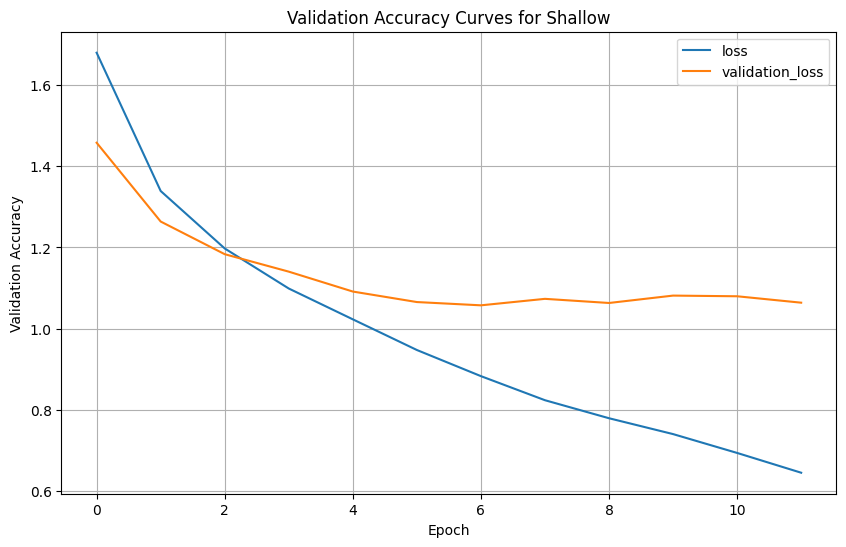

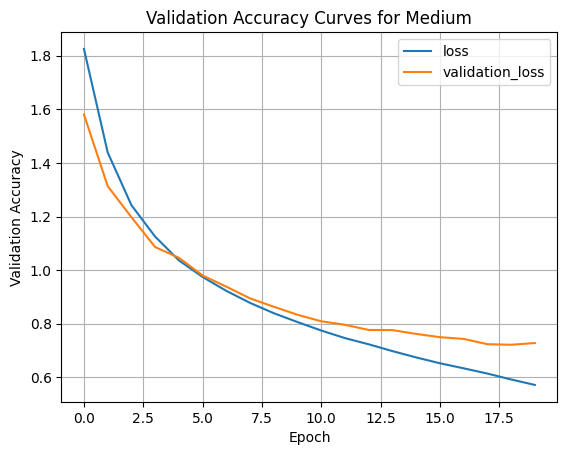

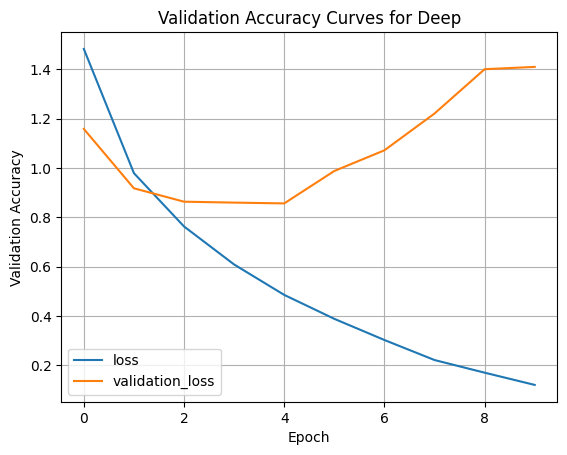

In [34]:
plt.figure(figsize=(10,6))

plt.plot(h_small.history['loss'], label='loss')
plt.plot(h_small.history['val_loss'], label='validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Curves for Shallow')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(h_medium.history['loss'], label='loss')
plt.plot(h_medium.history['val_loss'], label='validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Curves for Medium')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(h_large.history['loss'], label='loss')
plt.plot(h_large.history['val_loss'], label='validation_loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Curves for Deep')
plt.legend()
plt.grid(True)
plt.show()


Task 3: Regularization Experiments

In [35]:
def build_medium_dropout(rate=0.0):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        *( [layers.Dropout(rate)] if rate > 0 else [] ),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        *( [layers.Dropout(rate)] if rate > 0 else [] ),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        *( [layers.Dropout(rate)] if rate > 0 else [] ),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

3A: Dropout Comparison (D0, D1, D2)

Training with Dropout Rate: 0.0...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7026 | Test Loss: 2.4489 | Time: 109.6s
Training with Dropout Rate: 0.25...
Test Acc: 0.7648 | Test Loss: 0.9369 | Time: 115.2s
Training with Dropout Rate: 0.5...
Test Acc: 0.7882 | Test Loss: 0.6226 | Time: 115.2s

Table 3A: Dropout Results
    Model  Train Acc  Val Acc  Test Acc  Overfit Gap   Time (s)
 D0 (0.0)   0.986150   0.7128    0.7026     0.273350 109.603565
D1 (0.25)   0.930925   0.7688    0.7648     0.162125 115.185559
 D2 (0.5)   0.789750   0.7921    0.7882    -0.002350 115.206192


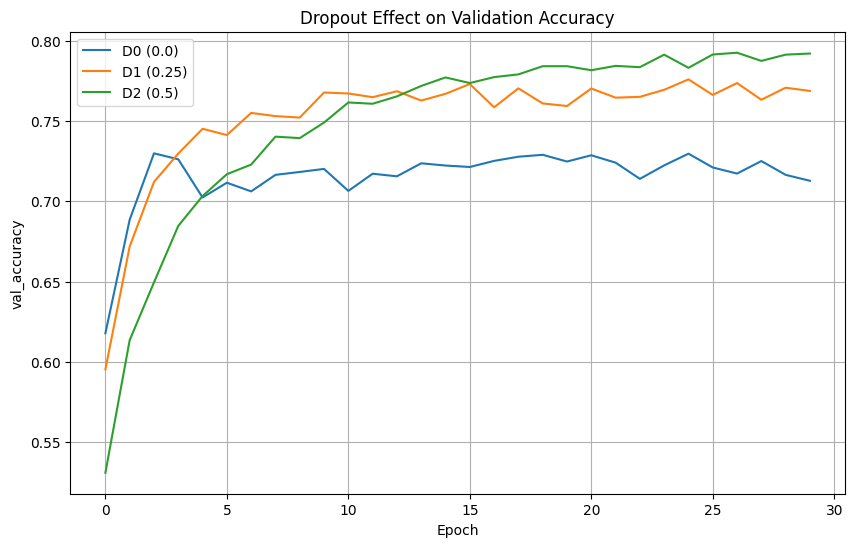

In [36]:
import pandas as pd
dropout_rates = [0.0, 0.25, 0.5]
results_dropout = []
histories_dropout = []

for rate in dropout_rates:
    print(f"Training with Dropout Rate: {rate}...")
    model = build_medium_dropout(rate)
    h, acc, loss, t = train_and_evaluate(
        model,
        x_train_standarized, y_train,
        x_val_standarized, y_val,
        x_test_standarized, y_test,
        epochs=30, batch_size=128
    )

    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    results_dropout.append({
        'Model': f"D{dropout_rates.index(rate)} ({rate})",
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Test Acc': acc,
        'Overfit Gap': train_acc - val_acc,
        'Time (s)': t
    })
    histories_dropout.append(h)

# Display Table 3A
df_dropout = pd.DataFrame(results_dropout)
print("\nTable 3A: Dropout Results")
print(df_dropout.to_string(index=False))

# Plotting 3A
plot_curves(histories_dropout, ["D0 (0.0)", "D1 (0.25)", "D2 (0.5)"], metric='val_accuracy', title='Dropout Effect on Validation Accuracy')

3B: Early Stopping Comparison


Starting Task 3B: Early Stopping Experiments...
Training ES0 (No Early Stopping)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7192 | Test Loss: 3.0509 | Time: 180.2s
Training ES2 (Patience = 5)...
Test Acc: 0.7082 | Test Loss: 0.8277 | Time: 34.8s
Training ES3 (Patience = 10)...
Test Acc: 0.7189 | Test Loss: 0.8156 | Time: 52.2s

Table 3B: Early Stopping Comparison Results
Experiment  Stopped at Epoch Best Val Loss Test Acc Time (s)
       ES0                50        0.8377   0.7192   180.17
       ES2                 8        0.8239   0.7082    34.82
       ES3                13        0.7946   0.7189    52.16


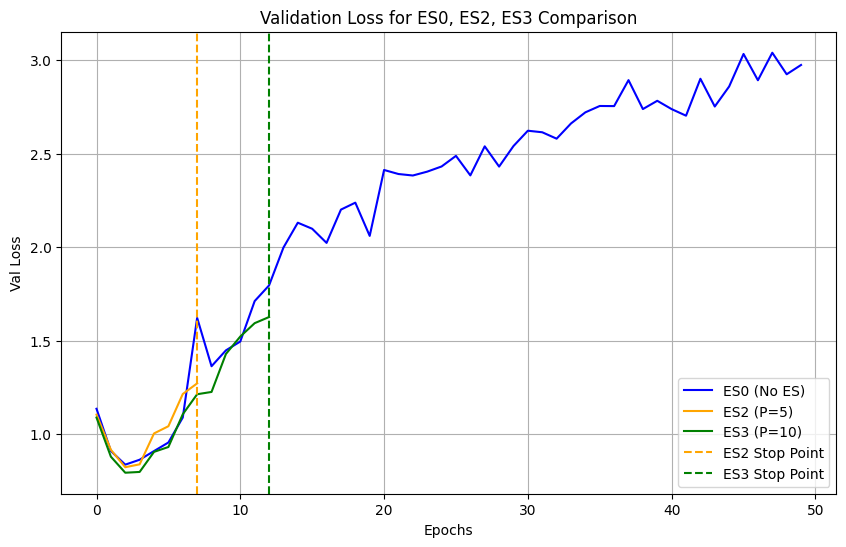

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks

e_best_weights=True #ensures we keep the best model found during training
es5 = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
es10 = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nStarting Task 3B: Early Stopping Experiments...")

# Helper function to extract and format metrics for the table
def get_metrics(h, acc, t):
    return len(h.history['loss']), min(h.history['val_loss']), acc, t

# 1. Experiment ES0: Baseline with No Early Stopping (Train for full 50 epochs)
print("Training ES0 (No Early Stopping)...")
h0, acc0, _, t0 = train_and_evaluate(
    build_medium_dropout(0.0),
    x_train_standarized, y_train,
    x_val_standarized, y_val,
    x_test_standarized, y_test,
    epochs=50, batch_size=128
)
res0 = get_metrics(h0, acc0, t0)

# 2. Experiment ES2: Early Stopping with Patience = 5
print("Training ES2 (Patience = 5)...")
h2, acc2, _, t2 = train_and_evaluate(
    build_medium_dropout(0.0),
    x_train_standarized, y_train,
    x_val_standarized, y_val,
    x_test_standarized, y_test,
    epochs=50, batch_size=128,
    extra_callbacks=[es5]
)
res2 = get_metrics(h2, acc2, t2)

# 3. Experiment ES3: Early Stopping with Patience = 10
print("Training ES3 (Patience = 10)...")
h3, acc3, _, t3 = train_and_evaluate(
    build_medium_dropout(0.0),
    x_train_standarized, y_train,
    x_val_standarized, y_val,
    x_test_standarized, y_test,
    epochs=50, batch_size=128,
    extra_callbacks=[es10]
)
res3 = get_metrics(h3, acc3, t3)

# --- Results Presentation ---

# Create the results dictionary to match the required table format
final_es_data = [
    {'Experiment': 'ES0', 'Stopped at Epoch': res0[0], 'Best Val Loss': f"{res0[1]:.4f}", 'Test Acc': f"{res0[2]:.4f}", 'Time (s)': f"{res0[3]:.2f}"},
    {'Experiment': 'ES2', 'Stopped at Epoch': res2[0], 'Best Val Loss': f"{res2[1]:.4f}", 'Test Acc': f"{res2[2]:.4f}", 'Time (s)': f"{res2[3]:.2f}"},
    {'Experiment': 'ES3', 'Stopped at Epoch': res3[0], 'Best Val Loss': f"{res3[1]:.4f}", 'Test Acc': f"{res3[2]:.4f}", 'Time (s)': f"{res3[3]:.2f}"}
]

# Print the final results table using Pandas
print("\n" + "="*70)
print("Table 3B: Early Stopping Comparison Results")
print("="*70)
print(pd.DataFrame(final_es_data).to_string(index=False))

# Plot Validation Loss curves for comparison
plt.figure(figsize=(10,6))
plt.plot(h0.history['val_loss'], label='ES0 (No ES)', color='blue')
plt.plot(h2.history['val_loss'], label='ES2 (P=5)', color='orange')
plt.plot(h3.history['val_loss'], label='ES3 (P=10)', color='green')

# Draw vertical lines to mark the exact stopping points for ES2 and ES3
plt.axvline(x=res2[0]-1, color='orange', linestyle='--', label='ES2 Stop Point')
plt.axvline(x=res3[0]-1, color='green', linestyle='--', label='ES3 Stop Point')

plt.title('Validation Loss for ES0, ES2, ES3 Comparison')
plt.xlabel('Epochs')
plt.ylabel('Val Loss')
plt.legend()
plt.grid(True)
plt.show()

Task 4: Optimizer Comparison & LR Sensitivity

4A: Optimizers Comparison

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import optimizers
opts = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

results_4a = []
histories_4a = []

print("Running Task 4A: Optimizer Experiments (this may take a few minutes)...")
for name, opt in opts.items():
    print(f"  Current Training: {name}")
    model = build_medium_dropout(rate=0.0)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    h, acc, loss, t = train_and_evaluate(
        model, x_train_standarized, y_train,
        x_val_standarized, y_val, x_test_standarized, y_test,
        epochs=30, batch_size=128
    )

    results_4a.append({
        'Optimizer': name,
        'Train Loss': f"{h.history['loss'][-1]:.4f}",
        'Val Loss': f"{h.history['val_loss'][-1]:.4f}",
        'Test Acc': f"{acc:.4f}",
        'Time (s)': f"{t:.2f}"
    })
    histories_4a.append(h)


Running Task 4A: Optimizer Experiments (this may take a few minutes)...
  Current Training: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5165 | Test Loss: 1.3600 | Time: 107.8s
  Current Training: Momentum
Test Acc: 0.6384 | Test Loss: 1.3833 | Time: 110.1s
  Current Training: AdaGrad
Test Acc: 0.5720 | Test Loss: 1.2267 | Time: 109.7s
  Current Training: RMSProp
Test Acc: 0.7232 | Test Loss: 3.3873 | Time: 108.9s
  Current Training: Adam
Test Acc: 0.7312 | Test Loss: 2.2293 | Time: 110.5s


4B: Learning Rate Sensitivity (Adam)

In [40]:
lrs = [0.0001, 0.001, 0.01]
results_4b = []
histories_4b = []

print("Running Task 4B: Learning Rate Experiments...")
for lr in lrs:
    print(f"  Current Training: Adam with LR = {lr}")
    model = build_medium_dropout(rate=0.0)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    h, acc, loss, t = train_and_evaluate(
        model, x_train_standarized, y_train,
        x_val_standarized, y_val, x_test_standarized, y_test,
        epochs=30, batch_size=128
    )

    results_4b.append({
        'LR': lr,
        'Train Loss': f"{h.history['loss'][-1]:.4f}",
        'Val Loss': f"{h.history['val_loss'][-1]:.4f}",
        'Test Acc': f"{acc:.4f}"
    })
    histories_4b.append(h)

Running Task 4B: Learning Rate Experiments...
  Current Training: Adam with LR = 0.0001
Test Acc: 0.6605 | Test Loss: 1.3988 | Time: 112.8s
  Current Training: Adam with LR = 0.001
Test Acc: 0.7142 | Test Loss: 2.6408 | Time: 110.3s
  Current Training: Adam with LR = 0.01
Test Acc: 0.1000 | Test Loss: 2.3032 | Time: 105.8s


Display Final Tables and Graphs


==================== TABLE 4A: OPTIMIZER RESULTS ====================
Optimizer Train Loss Val Loss Test Acc Time (s)
      SGD     1.3180   1.3825   0.5165   107.83
 Momentum     0.3803   1.3486   0.6384   110.09
  AdaGrad     1.1257   1.2446   0.5720   109.70
  RMSProp     0.0339   3.3529   0.7232   108.88
     Adam     0.0420   2.1813   0.7312   110.52

==================== TABLE 4B: LEARNING RATE RESULTS ====================
    LR Train Loss Val Loss Test Acc
0.0001     0.2640   1.4090   0.6605
0.0010     0.0306   2.5999   0.7142
0.0100     2.3034   2.3035   0.1000


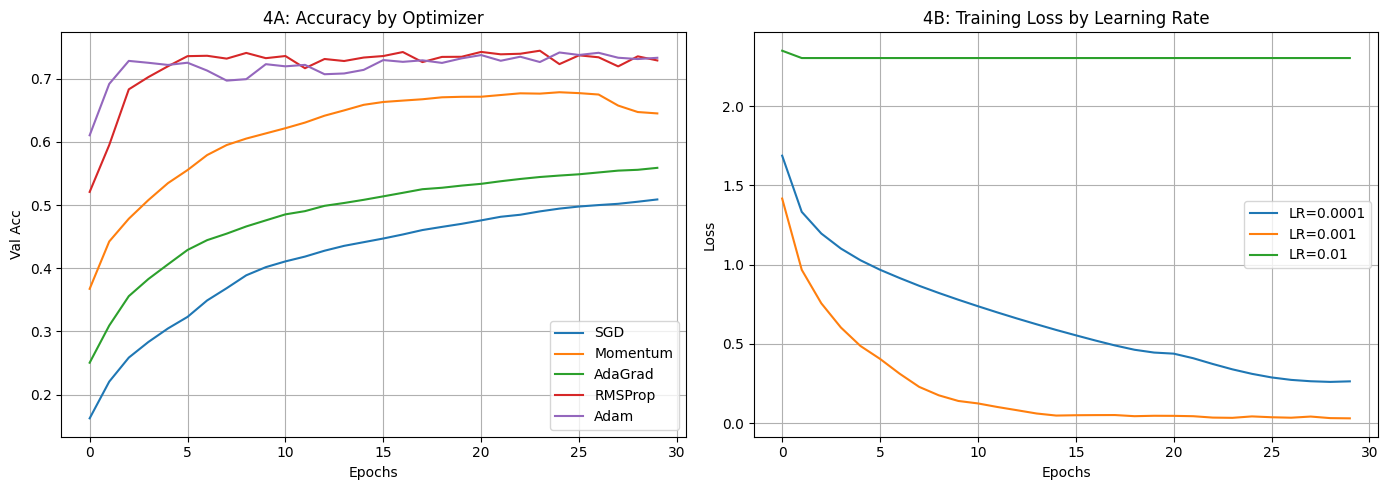

In [41]:
print("\n" + "="*20 + " TABLE 4A: OPTIMIZER RESULTS " + "="*20)
print(pd.DataFrame(results_4a).to_string(index=False))

print("\n" + "="*20 + " TABLE 4B: LEARNING RATE RESULTS " + "="*20)
print(pd.DataFrame(results_4b).to_string(index=False))

# Requirement: Final Plots
plt.figure(figsize=(14, 5))

# Plot 4A
plt.subplot(1, 2, 1)
for i, name in enumerate(opts.keys()):
    plt.plot(histories_4a[i].history['val_accuracy'], label=name)
plt.title('4A: Accuracy by Optimizer'); plt.xlabel('Epochs'); plt.ylabel('Val Acc'); plt.legend(); plt.grid(True)

# Plot 4B
plt.subplot(1, 2, 2)
for i, lr in enumerate(lrs):
    plt.plot(histories_4b[i].history['loss'], label=f'LR={lr}')
plt.title('4B: Training Loss by Learning Rate'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

Task 5

Best Model Architecture

In [54]:
def build_best_model(input_shape=(32,32,3)):
    
    model = models.Sequential([
        
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Data Augmentation

In [56]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_standarized)

Early Stopping

In [58]:
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

Train Best Model

In [61]:
best_model = build_best_model()

history_best = best_model.fit(
    datagen.flow(x_train_standarized, to_categorical(y_train,10), batch_size=128),
    validation_data=(x_val_standarized, to_categorical(y_val,10)),
    epochs=50,
    callbacks=[es]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.3081 - loss: 1.8816 - val_accuracy: 0.5407 - val_loss: 1.3017
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.4947 - loss: 1.3962 - val_accuracy: 0.5933 - val_loss: 1.1487
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.5583 - loss: 1.2274 - val_accuracy: 0.6437 - val_loss: 0.9953
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.6000 - loss: 1.1241 - val_accuracy: 0.6813 - val_loss: 0.9037
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6261 - loss: 1.0548 - val_accuracy: 0.6980 - val_loss: 0.8689
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6449 - loss: 1.0083 - val_accuracy: 0.7086 - val_loss: 0.8570
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6601 - loss: 0.9646 - val_accuracy: 0.7083 - val_loss: 0.8493
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6744 - loss: 0.9243 - val_accurac

Final Test Accuracy

In [63]:
test_loss, test_acc = best_model.evaluate(
    x_test_standarized,
    to_categorical(y_test,10),
    verbose=0
)

print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.785099983215332


Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


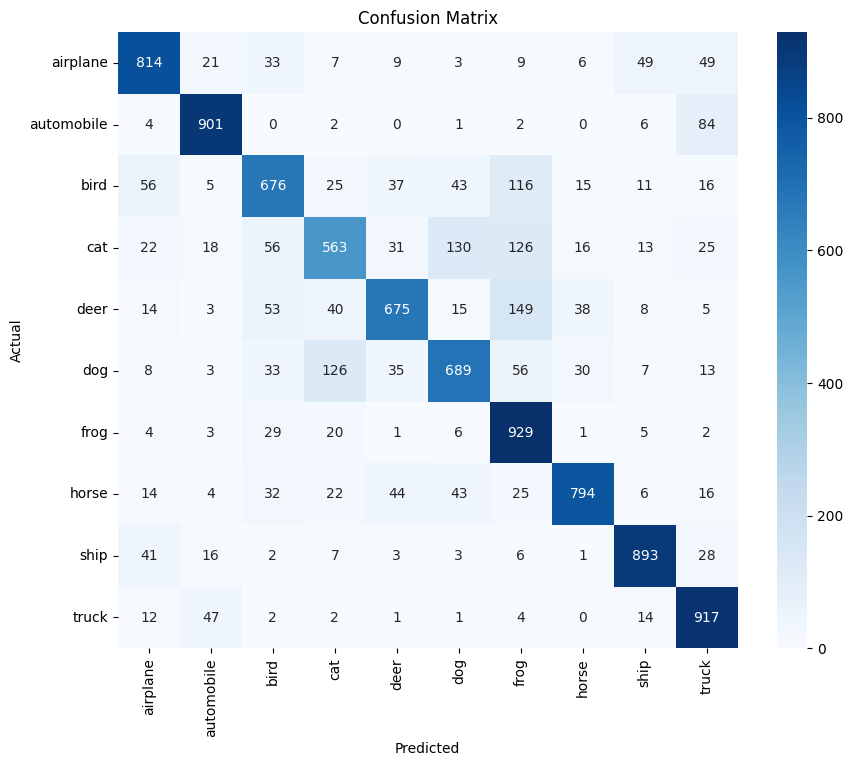

              precision    recall  f1-score   support

    airplane       0.82      0.81      0.82      1000
  automobile       0.88      0.90      0.89      1000
        bird       0.74      0.68      0.71      1000
         cat       0.69      0.56      0.62      1000
        deer       0.81      0.68      0.74      1000
         dog       0.74      0.69      0.71      1000
        frog       0.65      0.93      0.77      1000
       horse       0.88      0.79      0.84      1000
        ship       0.88      0.89      0.89      1000
       truck       0.79      0.92      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000



In [64]:
y_pred = np.argmax(best_model.predict(x_test_standarized), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Task 5B — Error Analysis
Misclassified Images

In [65]:
misclassified_idx = np.where(y_pred != y_test.flatten())[0]

print("Total misclassified:", len(misclassified_idx))

Total misclassified: 2149


Show Misclassified Images

In [73]:
def show_misclassified(true_class, n=5):

    idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]

    fig, axes = plt.subplots(1, n, figsize=(15,3))

    for ax, i in zip(axes, idx):

        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(
            f"True: {CLASS_NAMES[y_test[i][0]]}\nPred: {CLASS_NAMES[y_pred[i]]}"
        )
        ax.axis("off")

    plt.suptitle(f"Misclassified {CLASS_NAMES[true_class]}")
    plt.tight_layout()
    plt.show()

Task 6 — Transfer Learning
Step 1 — Resize Images for VGG16

In [75]:
x_train_resized = tf.image.resize(x_train_standarized, (48,48)).numpy()
x_val_resized   = tf.image.resize(x_val_standarized, (48,48)).numpy()
x_test_resized  = tf.image.resize(x_test_standarized, (48,48)).numpy()

Model 1 - From Scratch

In [79]:
def build_scratch_model():

    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(48,48,3)),
        layers.Conv2D(32,(3,3),activation='relu',padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),activation='relu',padding='same'),
        layers.Conv2D(64,(3,3),activation='relu',padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Train

In [80]:
model_scratch = build_scratch_model()

history_scratch, acc_scratch, loss_scratch, time_scratch = train_and_evaluate(
    model_scratch,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6739 | Test Loss: 2.9062 | Time: 151.2s


Model 2 - Feature Extraction (Frozen VGG16)

In [81]:
base_model = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48,48,3)
)

base_model.trainable = False

x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_feature = keras.Model(base_model.input, outputs)

model_feature.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Train

In [82]:
history_feature, acc_feature, loss_feature, time_feature = train_and_evaluate(
    model_feature,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test,
    epochs=20
)

Test Acc: 0.6978 | Test Loss: 0.8949 | Time: 407.4s


Model 3 - Fine-Tuning (lr=1e-5)

In [84]:
base_model_ft = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48,48,3)
)

for layer in base_model_ft.layers[:-4]:
    layer.trainable = False

for layer in base_model_ft.layers[-4:]:
    layer.trainable = True

x = base_model_ft.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_ft_low = keras.Model(base_model_ft.input, outputs)

model_ft_low.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [85]:
history_ft_low, acc_ft_low, loss_ft_low, time_ft_low = train_and_evaluate(
    model_ft_low,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test,
    epochs=20
)

Test Acc: 0.8250 | Test Loss: 0.5404 | Time: 495.9s


Model 4 - Fine-Tuning (lr=0.001)

In [86]:
model_ft_high = keras.models.clone_model(model_ft_low)

model_ft_high.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft_high, acc_ft_high, loss_ft_high, time_ft_high = train_and_evaluate(
    model_ft_high,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test,
    epochs=20
)

Test Acc: 0.4991 | Test Loss: 1.4882 | Time: 483.3s


Plot Validation Accuracy (All 4 Models)

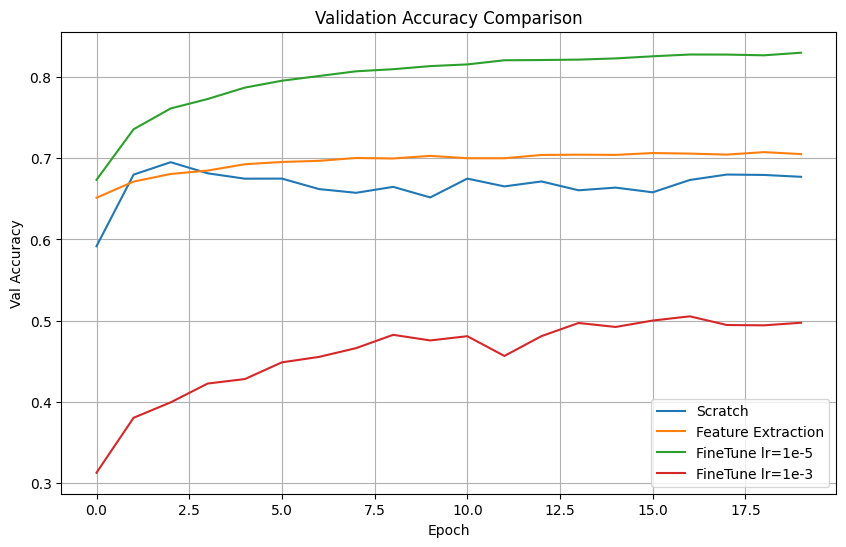

In [87]:
plot_curves(
    [history_scratch, history_feature, history_ft_low, history_ft_high],
    ["Scratch", "Feature Extraction", "FineTune lr=1e-5", "FineTune lr=1e-3"],
    metric='val_accuracy',
    title="Validation Accuracy Comparison",
    ylabel="Val Accuracy"
)